# The Wildlife Trade in Four Dimensions

In this notebook I aim to explore how 'bad' wildlife trade is in different countries. Measuring and visualizing what exactly is 'bad' turned out to be the most challenging as no single metric by itself is enough. I ended up with this combination:
- the export volume
- the wild-sourced proportion of the exports
- primary purpose of export
- unique species exported

**Data.** *Full CITES Trade Database Download*, Version 2025.1, compiled by UNEP-WCMC for the
CITES Secretariat. Available at [trade.cites.org](https://trade.cites.org).

The download is 56 CSV files totalling roughly 4.3 GB and 27.9 million trade records, so it
is not committed here. See [`data/README.md`](../data/README.md) for how to fetch it.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

import glob

import numpy as np
from adjustText import adjust_text

## Loading 27.9 million records

The CITES Trade Database consists of 56 separate files with six columns that I need. Glob handled this surprisingly quickly.


In [2]:
files = glob.glob("../data/trade_database/trade_db_*.csv")
columns = ["Year", "Taxon", "Quantity", "Exporter", "Purpose", "Source"]

print(f"{len(files)} files to read")

chunks = []
for path in files:
    try:
        chunks.append(pd.read_csv(path, usecols=columns, low_memory=False))
    except Exception as exc:
        print(f"skipped {path}: {exc}")

cites = pd.concat(chunks, ignore_index=True)
print(f"{len(cites):,} trade records loaded")
cites.head()

56 files to read


27,901,870 trade records loaded


,Year,Taxon,Quantity,Exporter,Purpose,Source
0,1984,Abies guatemalensis,20.0,GT,NaN,I
1,1984,Abies guatemalensis,20.0,GT,NaN,I
2,1984,Abies guatemalensis,40.0,GT,NaN,I
3,1984,Abies guatemalensis,20.0,GT,NaN,I
4,1985,Abies guatemalensis,750.0,GT,NaN,I


## Reducing to one row per exporter

`Source == "W"` means captured from the wild. I'm only interested in the wild-sourced share, not the total wild volume. 


In [3]:
cites["Wild_Qty"] = np.where(cites["Source"] == "W", cites["Quantity"], 0)

exporters = (
    cites.groupby("Exporter")
    .agg(
        Total_Volume=("Quantity", "sum"),
        Wild_Volume=("Wild_Qty", "sum"),
        Unique_Species=("Taxon", "nunique"),
        Top_Purpose=("Purpose", lambda s: s.mode()[0] if not s.mode().empty else "Unknown"),
    )
    .reset_index()
)

exporters["Wild_Percentage"] = exporters["Wild_Volume"] / exporters["Total_Volume"] * 100

print(f"{len(exporters)} exporting countries")
exporters.head()

259 exporting countries


,Exporter,Total_Volume,Wild_Volume,Unique_Species,Top_Purpose,Wild_Percentage
0,AD,1.648750e+03,2.700000e+01,22,T,1.637604
1,AE,1.392895e+08,7.143480e+07,638,T,51.285142
2,AF,8.693000e+03,8.358000e+03,30,P,96.146325
3,AG,6.790786e+04,5.637743e+04,78,P,83.020470
4,AI,1.225581e+04,1.069181e+04,18,P,87.238707


In [4]:
PURPOSES = {
    "T": "Commercial",
    "E": "Educational",
    "H": "Hunting Trophy",
    "L": "Law Enforcement/Judicial/Forensic",
    "M": "Medical",
    "N": "Reintroduction or Introduction Into the Wild",
    "P": "Personal",
    "Q": "Circus and Travelling Exhibitions",
    "S": "Scientific",
    "Z": "Zoo",
    "G": "Botanical Garden",
    "B": "Breeding",
}

exporters["Top_Purpose"] = exporters["Top_Purpose"].replace(PURPOSES)
exporters = exporters.rename(
    columns={"Top_Purpose": "Top Purpose", "Unique_Species": "Unique Species"}
)

# The countries with high volume and mostly wild-sourced
VOLUME_THRESHOLD = 10**8.5
WILD_THRESHOLD = 10

flagged = exporters[
    (exporters["Total_Volume"] > VOLUME_THRESHOLD)
    & (exporters["Wild_Percentage"] > WILD_THRESHOLD)
]

flagged[["Exporter", "Total_Volume", "Wild_Percentage", "Unique Species", "Top Purpose"]]

,Exporter,Total_Volume,Wild_Percentage,Unique Species,Top Purpose
42,CH,2.992330e+09,22.167489,3869,Commercial
58,DE,2.856877e+09,81.808608,7150,Commercial
76,FR,4.612726e+09,14.833044,3225,Commercial
80,GE,5.484837e+08,81.243290,202,Commercial
103,ID,3.365279e+08,64.980385,2467,Commercial
112,IT,2.408296e+09,69.799821,2006,Commercial
116,JP,4.362864e+08,12.748325,3443,Commercial
159,MX,1.155958e+09,97.167245,2070,Commercial
167,NL,7.054014e+08,16.648858,4744,Commercial
189,PY,2.278057e+09,99.739193,368,Commercial


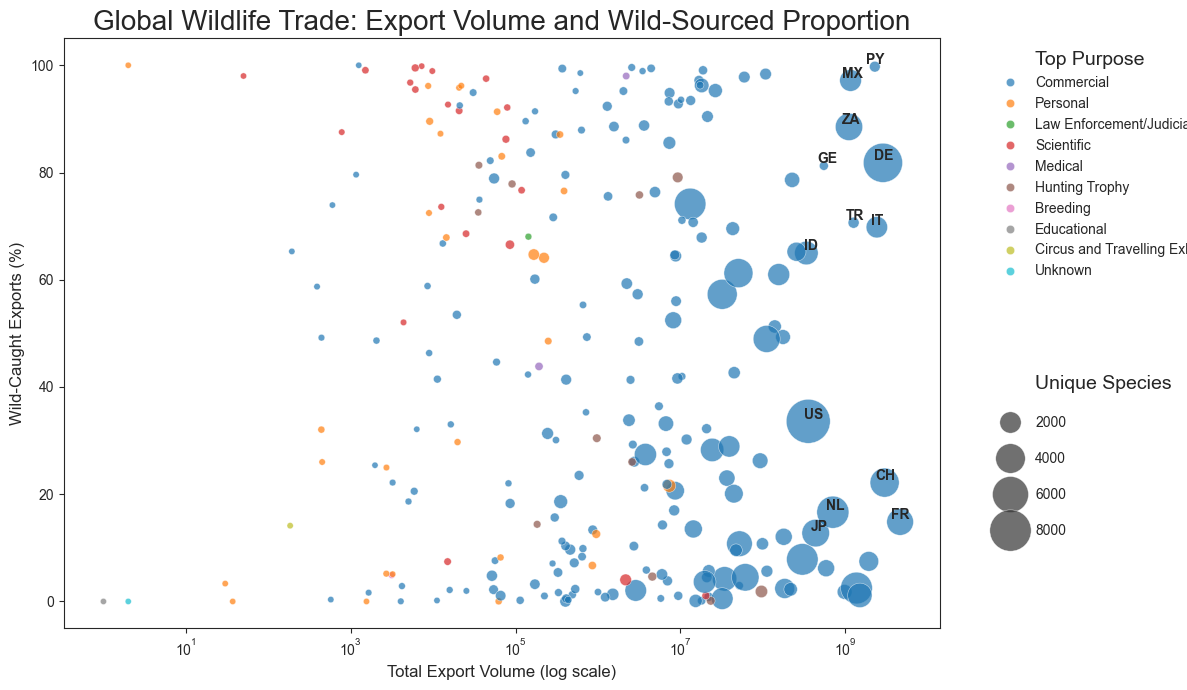

In [5]:
plt.figure(figsize=(12, 7))
sns.set_style("ticks")

ax = sns.scatterplot(
    data=exporters,
    x="Total_Volume",
    y="Wild_Percentage",
    size="Unique Species",
    hue="Top Purpose",
    sizes=(20, 1000),
    alpha=0.7,
)

labels = [
    plt.text(row.Total_Volume, row.Wild_Percentage, row.Exporter, fontsize=10, weight="bold")
    for row in flagged.itertuples()
]
adjust_text(labels)

plt.xscale("log")
plt.title("Global Wildlife Trade: Export Volume and Wild-Sourced Proportion", fontsize=20)
plt.xlabel("Total Export Volume (log scale)", fontsize=12)
plt.ylabel("Wild-Caught Exports (%)", fontsize=12)
plt.tick_params(axis="both", which="both", labelsize=10)

handles, texts = ax.get_legend_handles_labels()
split = texts.index("Unique Species")

purpose_legend = plt.legend(
    handles[:split], texts[:split],
    bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10,
)
size_legend = plt.legend(
    handles[split:], texts[split:],
    bbox_to_anchor=(1.05, 0.45), loc="upper left", fontsize=10, labelspacing=1.6,
)
for legend in (purpose_legend, size_legend):
    legend.get_texts()[0].set_fontsize(14)

ax.add_artist(purpose_legend)

plt.tight_layout()
plt.savefig("../figures/04-wildlife-trade-multivariate.png", dpi=150, bbox_inches="tight")
plt.show()

## Results

The most alarming countries are in the top-right corner; Paraguay, South Africa and Mexico export a large volume of wildlife sourced from the wild. This is unsustainable and can lead to species endangerment and extinction – especially when the number of unique species exported is low. An interesting observation is that most of the exports are for commercial purposes, meaning food industry and furniture, for example. Countries with the most total export volume export wildlife primarily for commercial purposes.

**Design notes:** The dot positions are determined by volume and wild-sourced share. Position is the channel people read most accurately, so it should carry the two variables that matter most. The size of the circles and their color are only additional information that, while interesting and useful, are not as important. I chose to include some of the country codes to reveal the most alarming and interesting countries. The circle sizes still need to be distinguishable – that is, the largest need to be large enough compared to the smaller circles so that comparisons can easily be made.
